**需要切换环境到finance_RAG**

In [1]:

import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
from PIL import Image
from io import BytesIO
import torch
from transformers import AutoModel
import gc

# 显存监控函数
def print_gpu_memory(stage="", device=9):
    if torch.cuda.is_available():
        torch.cuda.set_device(device)
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        print(f"[{stage}] GPU Memory - Allocated: {allocated:.2f}GB, Reserved: {reserved:.2f}GB")

def clear_gpu_memory():
    """清理GPU显存"""
    gc.collect()
    torch.cuda.empty_cache()

print("工具函数已加载")

/home/zechuan/miniconda3/envs/finance_RAG/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/zechuan/miniconda3/envs/finance_RAG/lib/python3.11/site-packages/transformers/utils/hub.py:106: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


工具函数已加载


In [2]:
print_gpu_memory("Before loading model")
# Load Model
retriever_model = AutoModel.from_pretrained(
    'nvidia/llama-nemoretriever-colembed-3b-v1',
    device_map='cuda:9',
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    attn_implementation="flash_attention_2",
    revision='50c36f4d5271c6851aa08bd26d69f6e7ca8b870c',
).eval()
print_gpu_memory("After loading model")

[Before loading model] GPU Memory - Allocated: 0.00GB, Reserved: 0.00GB


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.11it/s]

[After loading model] GPU Memory - Allocated: 8.21GB, Reserved: 8.34GB


In [3]:
import requests
queries = [
    'How much percentage of Germanys population died in the 2nd World War?',
    'How many million tons CO2 were captured from Gas processing in 2018?',
    'What is the average CO2 emission of someone in Japan?'
]

# Documents
image_urls = [
    'https://upload.wikimedia.org/wikipedia/commons/3/35/Human_losses_of_world_war_two_by_country.png',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/7/76/20210413_Carbon_capture_and_storage_-_CCS_-_proposed_vs_implemented.svg/2560px-20210413_Carbon_capture_and_storage_-_CCS_-_proposed_vs_implemented.svg.png',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/f/f3/20210626_Variwide_chart_of_greenhouse_gas_emissions_per_capita_by_country.svg/2880px-20210626_Variwide_chart_of_greenhouse_gas_emissions_per_capita_by_country.svg.png'
]

# Load into PIL
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

images = [Image.open(BytesIO(requests.get(image_url, headers=headers).content)) for image_url in image_urls]


In [4]:
# Encoding
query_embeddings = retriever_model.forward_queries(queries, batch_size=8)
passage_embeddings = retriever_model.forward_passages(images, batch_size=8)


scores = retriever_model.get_scores(
    query_embeddings,
    passage_embeddings
)
# Diagonal should have high scores
print(scores)

Extracting document embeddings...: 100%|██████████| 1/1 [00:01<00:00,  1.74s/it]


tensor([[13.4384, 10.1109, 11.3121],
        [11.0406, 14.4857, 11.2699],
        [ 9.2808,  9.0414, 10.9037]], device='cuda:9')


**以上是示例，读取网页图片**

In [5]:
from pdf2image import convert_from_path

# 加载本地PDF文件
pdf_path = 'contents/2024_Tencent_ESG.pdf'  

# 将PDF转换为图片列表（每一页一张图片）
# dpi设置过大会导致内存过载而kernel崩溃
images = convert_from_path(pdf_path, dpi=200)  # dpi可调整图片质量

print(f"PDF共有 {len(images)} 页")

PDF共有 111 页


In [6]:
# 定义查询问题
queries = [
    '2022年员工总数是多少？',
    '截至二零二四年温室气体排放总量是多少？',
    '截至二零二四年每收入单位的温室气体排放总量是多少？'
]
print_gpu_memory("Before query encoding")
# 对查询进行编码
query_embeddings = retriever_model.forward_queries(queries, batch_size=8)
print_gpu_memory("After query encoding")

# 优化：立即移到CPU
query_embeddings_cpu = query_embeddings.cpu()
del query_embeddings
clear_gpu_memory()
print_gpu_memory("After moving query to CPU")
# 对文档进行编码
passage_embeddings = retriever_model.forward_passages(images, batch_size=8)
print_gpu_memory("After passage encoding")

# 优化：立即移到CPU
passage_embeddings_cpu = passage_embeddings.cpu()
del passage_embeddings
clear_gpu_memory()
print_gpu_memory("After moving passage to CPU")

[Before query encoding] GPU Memory - Allocated: 8.21GB, Reserved: 10.32GB


Extracting query embeddings...: 100%|██████████| 1/1 [00:02<00:00,  2.01s/it]


[After query encoding] GPU Memory - Allocated: 8.21GB, Reserved: 10.33GB
[After moving query to CPU] GPU Memory - Allocated: 8.21GB, Reserved: 8.34GB


Extracting document embeddings...: 100%|██████████| 14/14 [00:38<00:00,  2.75s/it]


[After passage encoding] GPU Memory - Allocated: 8.21GB, Reserved: 18.12GB
[After moving passage to CPU] GPU Memory - Allocated: 8.21GB, Reserved: 8.34GB


In [7]:
# 计算相似度分数
scores = retriever_model.get_scores(
    query_embeddings_cpu,
    passage_embeddings_cpu
)
# 设置top_k参数
top_k = 10  # 获取前k个最相关的页面

print(f"\n每个查询的前 {top_k} 个最相关页面：")
results_list = []

for i, query in enumerate(queries):
    # 获取当前查询的所有分数
    query_scores = scores[i]
    
    # 获取前k个最高分数的索引
    top_k_indices = query_scores.argsort(descending=True)[:top_k]
    
    # 获取对应的分数
    top_k_scores = [query_scores[idx].item() for idx in top_k_indices]
    
    # 存储结果
    query_results = {
        "query": query,
        "top_pages": []
    }
    
    print(f"\n查询 {i+1}: '{query}'")
    for rank, (page_idx, score) in enumerate(zip(top_k_indices, top_k_scores)):
        page_num = page_idx.item() + 1  # 转换为1-indexed
        query_results["top_pages"].append({
            "page_num": page_num,
            "page_index": page_idx.item(),
            "score": score,
            "rank": rank + 1
        })
        print(f"  {rank+1}. 第 {page_num} 页，分数: {score:.4f}")
    
    results_list.append(query_results)


每个查询的前 10 个最相关页面：

查询 1: '2022年员工总数是多少？'
  1. 第 77 页，分数: 10.4376
  2. 第 71 页，分数: 10.3832
  3. 第 90 页，分数: 10.3759
  4. 第 101 页，分数: 10.3692
  5. 第 63 页，分数: 10.2595
  6. 第 40 页，分数: 10.2233
  7. 第 75 页，分数: 10.2155
  8. 第 13 页，分数: 10.1507
  9. 第 55 页，分数: 10.0881
  10. 第 96 页，分数: 10.0686

查询 2: '截至二零二四年温室气体排放总量是多少？'
  1. 第 84 页，分数: 14.8085
  2. 第 95 页，分数: 14.7932
  3. 第 22 页，分数: 14.7653
  4. 第 66 页，分数: 14.7055
  5. 第 17 页，分数: 14.6958
  6. 第 108 页，分数: 14.6601
  7. 第 29 页，分数: 14.6492
  8. 第 100 页，分数: 14.6474
  9. 第 85 页，分数: 14.6398
  10. 第 21 页，分数: 14.5746

查询 3: '截至二零二四年每收入单位的温室气体排放总量是多少？'
  1. 第 100 页，分数: 17.1184
  2. 第 95 页，分数: 17.1160
  3. 第 84 页，分数: 17.0620
  4. 第 66 页，分数: 16.9976
  5. 第 17 页，分数: 16.9886
  6. 第 96 页，分数: 16.9592
  7. 第 22 页，分数: 16.9499
  8. 第 29 页，分数: 16.9367
  9. 第 82 页，分数: 16.9128
  10. 第 76 页，分数: 16.8750


In [8]:
from rerankers import Reranker

print_gpu_memory("Before loading reranker")
ranker = Reranker("monovlm", use_fast=True, device='cuda:9')
print_gpu_memory("After loading reranker")


[Before loading reranker] GPU Memory - Allocated: 8.21GB, Reserved: 8.84GB
Loading default monovlm model for language en
Default Model: lightonai/MonoQwen2-VL-v0.1
Loading MonoVLMRanker model lightonai/MonoQwen2-VL-v0.1 (this message can be suppressed by setting verbose=0)
bf16
Using dtype torch.bfloat16
Loading model lightonai/MonoQwen2-VL-v0.1, this might take a while...
Using device cuda:9.
Using dtype torch.bfloat16.


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.50it/s]


VLM true token set to True
VLM false token set to False
[After loading reranker] GPU Memory - Allocated: 12.40GB, Reserved: 12.86GB


In [9]:
# 从results_list中提取图片
def get_grouped_images(result_item, all_images):
    """
    从单个查询结果中提取对应的图片
    result_item: results_list中的一个元素，包含query和top_pages
    all_images: 所有图片的列表
    """
    grouped_images = []
    for page_info in result_item['top_pages']:
        page_index = page_info['page_index']
        grouped_images.append(all_images[page_index])
    return grouped_images

## 批量图片Reranking

以下代码实现了对多个查询的批量图片reranking功能，参考了`Multimodal_RAG_with_ColQwen2_Reranker.ipynb`的实现。

主要步骤：
1. 将检索到的候选图片转换为base64格式
2. 使用MonoVLM reranker对每个查询的候选图片进行重排序
3. 提取和可视化reranking后的最佳结果

In [10]:
# Base64转换函数（参考Multimodal_RAG_with_ColQwen2_Reranker.ipynb）
import base64
from io import BytesIO

def images_to_base64(images):
    """
    将PIL图片列表转换为base64编码列表
    """
    base64_images = []
    for img in images:
        buffer = BytesIO()
        img.save(buffer, format="JPEG")
        buffer.seek(0)
        
        img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")
        base64_images.append(img_base64)
    
    return base64_images

In [11]:
# 批量对所有查询进行图片reranking
reranked_results = []

print("开始批量reranking...")
print("="*80)

for idx, result in enumerate(results_list):
    query = result["query"]
    print(f"\n处理查询 {idx+1}/{len(results_list)}: {query}")
    print_gpu_memory(f"Query {idx+1} - Before")
    
    # 获取该查询的top_k图片
    grouped_images = get_grouped_images(result, images)
    print(f"  - 获取到 {len(grouped_images)} 张候选图片")
    
    # 转换为base64
    base64_list = images_to_base64(grouped_images)
    print(f"  - 转换为base64完成")
    
    # 使用reranker进行重排序
    print(f"  - 开始reranking...")
    rerank_results = ranker.rank(query, base64_list)
    print(f"  - Reranking完成")
    
    # 存储reranking结果
    reranked_results.append({
        'query': query,
        'original_results': result,
        'rerank_results': rerank_results,
        'grouped_images': grouped_images
    })

    # 优化：立即清理显存
    del base64_list
    clear_gpu_memory()
    print_gpu_memory(f"Query {idx+1} - After cleanup")
print("\n" + "="*80)
print(f"批量reranking完成！共处理 {len(reranked_results)} 个查询")
print_gpu_memory("Final state")

开始批量reranking...

处理查询 1/3: 2022年员工总数是多少？
[Query 1 - Before] GPU Memory - Allocated: 12.40GB, Reserved: 12.86GB
  - 获取到 10 张候选图片
  - 转换为base64完成
  - 开始reranking...
  - Reranking完成
[Query 1 - After cleanup] GPU Memory - Allocated: 12.40GB, Reserved: 12.81GB

处理查询 2/3: 截至二零二四年温室气体排放总量是多少？
[Query 2 - Before] GPU Memory - Allocated: 12.40GB, Reserved: 12.81GB
  - 获取到 10 张候选图片
  - 转换为base64完成
  - 开始reranking...
  - Reranking完成
[Query 2 - After cleanup] GPU Memory - Allocated: 12.40GB, Reserved: 12.81GB

处理查询 3/3: 截至二零二四年每收入单位的温室气体排放总量是多少？
[Query 3 - Before] GPU Memory - Allocated: 12.40GB, Reserved: 12.81GB
  - 获取到 10 张候选图片
  - 转换为base64完成
  - 开始reranking...
  - Reranking完成
[Query 3 - After cleanup] GPU Memory - Allocated: 12.40GB, Reserved: 12.81GB

批量reranking完成！共处理 3 个查询
[Final state] GPU Memory - Allocated: 12.40GB, Reserved: 12.81GB


In [12]:
# 处理reranking结果（参考Multimodal_RAG_with_ColQwen2_Reranker.ipynb）
def process_ranker_results(rerank_results, grouped_images, top_k=3, log=False):
    """
    处理reranker的结果，返回重排序后的top_k图片
    """
    new_grouped_images = []
    result_details = []
    
    for i, doc in enumerate(rerank_results.top_k(top_k)):
        if log:
            print(f"Rank {i+1}:")
            print(f"  Document ID: {doc.doc_id}")
            print(f"  Document Score: {doc.score:.4f}")
            if hasattr(doc, 'image_path') and doc.image_path:
                print(f"  Document Path: {doc.image_path}")
        
        new_grouped_images.append(grouped_images[doc.doc_id])
        result_details.append({
            'rank': i + 1,
            'doc_id': doc.doc_id,
            'score': doc.score
        })
    
    return new_grouped_images, result_details

In [13]:
# 显示所有查询的reranking结果详情
print("="*80)
print("Reranking结果详情")
print("="*80)

for idx, reranked_result in enumerate(reranked_results):
    query = reranked_result['query']
    print(f"\n查询 {idx+1}: {query}")
    print("-"*80)
    
    # 处理reranking结果并显示详细信息
    top_images, details = process_ranker_results(
        reranked_result['rerank_results'], 
        reranked_result['grouped_images'], 
        top_k=5,  # 显示前5个结果
        log=True
    )
    print()

Reranking结果详情

查询 1: 2022年员工总数是多少？
--------------------------------------------------------------------------------
Rank 1:
  Document ID: 3
  Document Score: 0.7500
Rank 2:
  Document ID: 5
  Document Score: 0.1641
Rank 3:
  Document ID: 2
  Document Score: 0.0198
Rank 4:
  Document ID: 9
  Document Score: 0.0103
Rank 5:
  Document ID: 0
  Document Score: 0.0087


查询 2: 截至二零二四年温室气体排放总量是多少？
--------------------------------------------------------------------------------
Rank 1:
  Document ID: 7
  Document Score: 1.0000
Rank 2:
  Document ID: 5
  Document Score: 0.8984
Rank 3:
  Document ID: 2
  Document Score: 0.1035
Rank 4:
  Document ID: 9
  Document Score: 0.0806
Rank 5:
  Document ID: 4
  Document Score: 0.0535


查询 3: 截至二零二四年每收入单位的温室气体排放总量是多少？
--------------------------------------------------------------------------------
Rank 1:
  Document ID: 0
  Document Score: 1.0000
Rank 2:
  Document ID: 6
  Document Score: 0.0074
Rank 3:
  Document ID: 4
  Document Score: 0.0037
Rank 4:
  

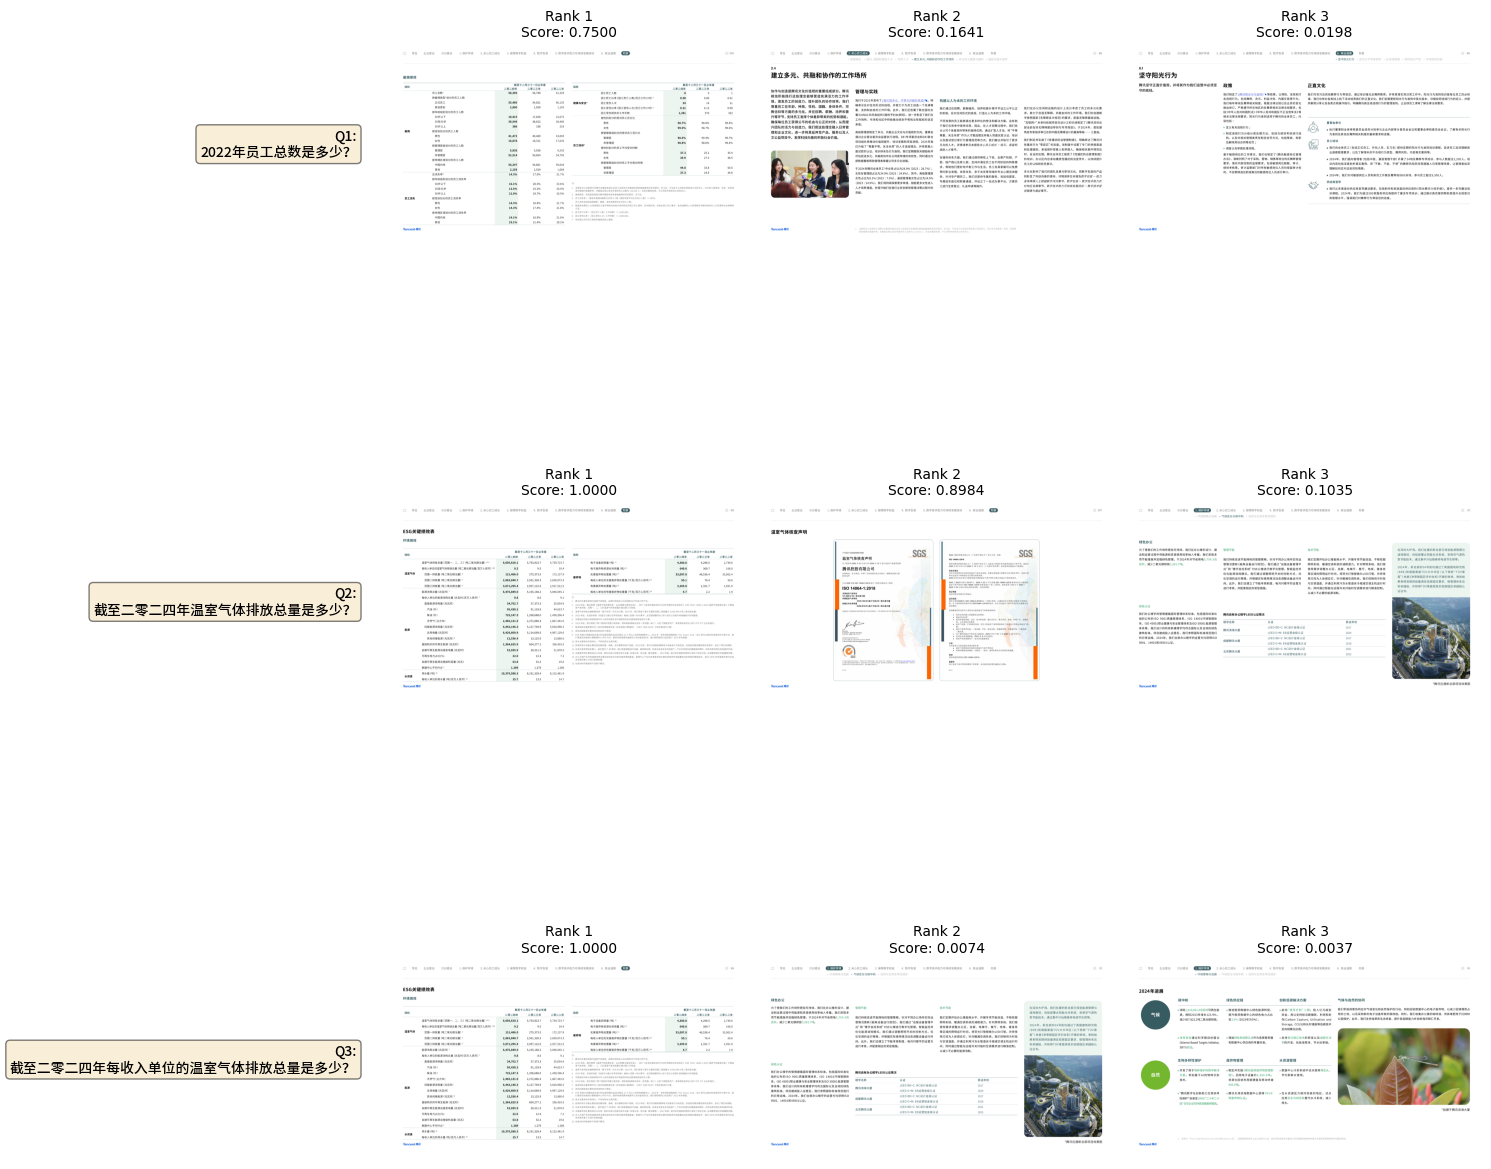

In [14]:
# 可视化：显示每个查询的top-3 reranked图片
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_path = "/mnt/SSD2_8TB/zechuan/noto-sans-sc/NotoSansSC-Medium.otf"  # 根据系统路径调整
font_prop = font_manager.FontProperties(fname=font_path)

num_queries = len(reranked_results)
top_k_display = 3  # 每个查询显示前3张图片

fig, axes = plt.subplots(num_queries, top_k_display, figsize=(15, 5*num_queries))

# 确保axes是二维数组
if num_queries == 1:
    axes = axes.reshape(1, -1)

for query_idx, reranked_result in enumerate(reranked_results):
    query = reranked_result['query']
    
    # 获取top-k reranked图片
    top_images, details = process_ranker_results(
        reranked_result['rerank_results'], 
        reranked_result['grouped_images'], 
        top_k=top_k_display,
        log=False
    )
    
    # 显示图片
    for img_idx, (img, detail) in enumerate(zip(top_images, details)):
        ax = axes[query_idx, img_idx]
        ax.imshow(img)
        ax.set_title(f"Rank {detail['rank']}\nScore: {detail['score']:.4f}", fontsize=10)
        ax.axis('off')
    
    # 在左侧添加查询文本
    axes[query_idx, 0].text(-0.1, 0.5, f"Q{query_idx+1}:\n{query}", 
                             transform=axes[query_idx, 0].transAxes,
                             fontsize=10, verticalalignment='center',
                             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                             rotation=0, ha='right',
                             fontproperties=font_prop)

plt.tight_layout()
plt.show()

In [15]:
# 提取每个查询的最佳结果（Reranking后的top-1）
best_results = []

print("="*80)
print("每个查询的最佳匹配结果（Reranking后）")
print("="*80)

for idx, reranked_result in enumerate(reranked_results):
    query = reranked_result['query']
    
    # 获取reranking后的top-1结果
    top_1_images, top_1_details = process_ranker_results(
        reranked_result['rerank_results'], 
        reranked_result['grouped_images'], 
        top_k=1,
        log=False
    )
    
    # 获取原始检索结果的top-1页面信息
    original_top_page = reranked_result['original_results']['top_pages'][0]
    
    # 获取reranking后的实际页面信息
    reranked_doc_id = top_1_details[0]['doc_id']
    reranked_page_info = reranked_result['original_results']['top_pages'][reranked_doc_id]
    
    best_results.append({
        'query': query,
        'best_image': top_1_images[0],
        'rerank_score': top_1_details[0]['score'],
        'original_page_num': original_top_page['page_num'],
        'original_retrieval_score': original_top_page['score'],
        'reranked_page_num': reranked_page_info['page_num'],
        'reranked_retrieval_score': reranked_page_info['score']
    })
    
    print(f"\n查询 {idx+1}: {query}")
    print(f"  原始检索Top-1: 第 {original_top_page['page_num']} 页 (检索分数: {original_top_page['score']:.4f})")
    print(f"  Reranking后: 第 {reranked_page_info['page_num']} 页 (Rerank分数: {top_1_details[0]['score']:.4f}, 检索分数: {reranked_page_info['score']:.4f})")
    if original_top_page['page_num'] != reranked_page_info['page_num']:
        print(f"  ⚠️ 结果发生变化！")
    else:
        print(f"  ✓ 结果保持不变")

每个查询的最佳匹配结果（Reranking后）

查询 1: 2022年员工总数是多少？
  原始检索Top-1: 第 77 页 (检索分数: 10.4376)
  Reranking后: 第 101 页 (Rerank分数: 0.7500, 检索分数: 10.3692)
  ⚠️ 结果发生变化！

查询 2: 截至二零二四年温室气体排放总量是多少？
  原始检索Top-1: 第 84 页 (检索分数: 14.8085)
  Reranking后: 第 100 页 (Rerank分数: 1.0000, 检索分数: 14.6474)
  ⚠️ 结果发生变化！

查询 3: 截至二零二四年每收入单位的温室气体排放总量是多少？
  原始检索Top-1: 第 100 页 (检索分数: 17.1184)
  Reranking后: 第 100 页 (Rerank分数: 1.0000, 检索分数: 17.1184)
  ✓ 结果保持不变


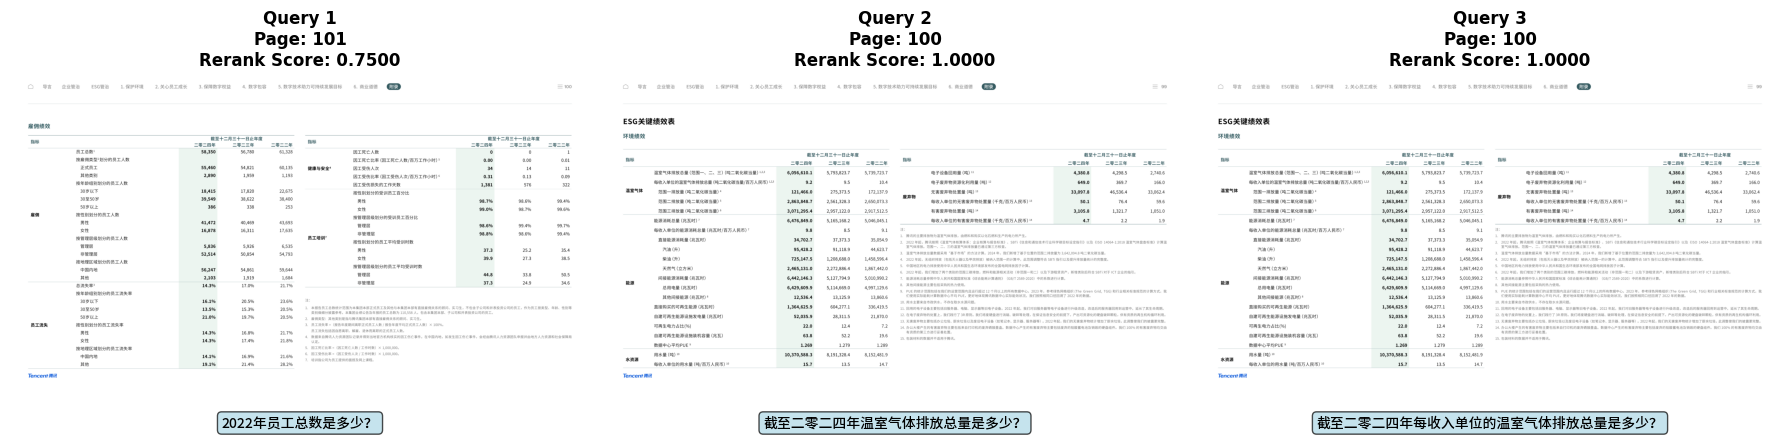

In [16]:
# 可视化：并排显示每个查询的最佳匹配图片
import matplotlib.pyplot as plt

num_queries = len(best_results)

fig, axes = plt.subplots(1, num_queries, figsize=(6*num_queries, 6))

# 确保axes是数组
if num_queries == 1:
    axes = [axes]

for idx, result in enumerate(best_results):
    ax = axes[idx]
    ax.imshow(result['best_image'])
    
    title = f"Query {idx+1}\nPage: {result['reranked_page_num']}\n"
    title += f"Rerank Score: {result['rerank_score']:.4f}"
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # 在图片下方添加查询文本
    ax.text(0.5, -0.05, result['query'], 
            transform=ax.transAxes,
            fontsize=10, 
            ha='center',
            va='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7),
            wrap=True,
            fontproperties=font_prop
            )

plt.tight_layout()
plt.show()

### Qwen2VL推理 OOM结果显示如下，还是调用Api吧

In [20]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
print_gpu_memory("Before loading VQA model")
# 加载Qwen2-VL模型用于问答
model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="cuda:9"
).cuda().eval()
print_gpu_memory("After loading VQA model")

print_gpu_memory("Before loading VQA Processor")
# 加载处理器
processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    trust_remote_code=True,
    device_map="cuda:9"
)
print_gpu_memory("After loading VQA Processor")

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


[Before loading VQA model] GPU Memory - Allocated: 9.63GB, Reserved: 18.24GB


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.38it/s]


[After loading VQA model] GPU Memory - Allocated: 13.75GB, Reserved: 17.95GB
[Before loading VQA Processor] GPU Memory - Allocated: 13.75GB, Reserved: 17.95GB
[After loading VQA Processor] GPU Memory - Allocated: 13.75GB, Reserved: 17.95GB


In [21]:
print_gpu_memory("Before unloading models")

# 卸载retriever模型
del retriever_model
print("Retriever model unloaded")

# 卸载reranker模型
del ranker
print("Ranker model unloaded")

# 清理显存
clear_gpu_memory()
print_gpu_memory("After unloading models")

print("\n现在可以安全加载VQA模型了，显存已释放")

[Before unloading models] GPU Memory - Allocated: 13.75GB, Reserved: 17.95GB


NameError: name 'retriever_model' is not defined

In [ ]:

from qwen_vl_utils import process_vision_info

for i, result in enumerate(best_results):
    query = result["query"]
    
    print(f"\n{'='*80}")
    print(f"问题 {i+1}: {query}")
    print('='*80)
    
        
    print(f"\n{'—'*40}")
    print(f"使用第 {result['reranked_page_num']} 页 (相似度分数: {result['reranked_retrieval_score']:.4f})")
    print('—'*40)
        
    # 准备消息格式
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": result['best_image'],
                },
                {"type": "text", "text": query},
            ],
        }
    ]
        
    # 准备输入
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
        
    image_inputs, video_inputs = process_vision_info(messages)
        
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    print_gpu_memory("Before inputs to GPU")
    inputs = inputs.to("cuda:9")
    print_gpu_memory("After inputs to GPU")   
    # 生成答案
    generated_ids = model.generate(**inputs, max_new_tokens=512)
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )
        
    print(f"答案: {output_text[0]}")


问题 1: 2022年员工总数是多少？

————————————————————————————————————————
使用第 101 页 (相似度分数: 10.3692)
————————————————————————————————————————
[Before inputs to GPU] GPU Memory - Allocated: 4.12GB, Reserved: 4.49GB
[After inputs to GPU] GPU Memory - Allocated: 4.41GB, Reserved: 4.77GB


OutOfMemoryError: CUDA out of memory. Tried to allocate 124.37 GiB. GPU 9 has a total capacity of 47.38 GiB of which 28.72 GiB is free. Including non-PyTorch memory, this process has 18.65 GiB memory in use. Of the allocated memory 17.71 GiB is allocated by PyTorch, and 543.26 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### 使用豆包API进行多模态问答

以下代码使用豆包API替代本地Qwen2-VL模型进行问答，避免显存不足的问题。

In [22]:
import os
from dotenv import load_dotenv
load_dotenv()
from openai import OpenAI

# 初始化API客户端
client = OpenAI(
    base_url="https://ark.cn-beijing.volces.com/api/v3",
    api_key=os.environ.get("ARK_API_KEY"),
)

print("豆包API客户端初始化完成")

豆包API客户端初始化完成


In [23]:
import base64
from io import BytesIO

def image_to_base64_url(image):
    """
    将PIL图片转换为base64 data URL格式
    """
    buffer = BytesIO()
    image.save(buffer, format="JPEG")
    buffer.seek(0)
    img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return f"data:image/jpeg;base64,{img_base64}"

print("图片转换函数已加载")

图片转换函数已加载


In [24]:
# 使用豆包API对每个查询进行问答
api_results = []

print("="*80)
print("使用豆包API进行问答")
print("="*80)

for i, result in enumerate(best_results):
    query = result["query"]
    best_image = result["best_image"]
    
    print(f"\n问题 {i+1}: {query}")
    print(f"使用第 {result['reranked_page_num']} 页 (Rerank分数: {result['rerank_score']:.4f})")
    
    # 将图片转换为base64 URL
    image_url = image_to_base64_url(best_image)
    
    try:
        # 调用API
        response = client.chat.completions.create(
            model="doubao-seed-1-6-vision-250815",
            messages=[
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": image_url
                            },
                        },
                        {"type": "text", "text": query},
                    ],
                }
            ],
        )
        
        answer = response.choices[0].message.content
        print(f"答案: {answer}")
        
        api_results.append({
            'query': query,
            'page_num': result['reranked_page_num'],
            'rerank_score': result['rerank_score'],
            'answer': answer,
            'image': best_image
        })
        
    except Exception as e:
        print(f"API调用出错: {str(e)}")
        api_results.append({
            'query': query,
            'page_num': result['reranked_page_num'],
            'rerank_score': result['rerank_score'],
            'answer': f"错误: {str(e)}",
            'image': best_image
        })

print("\n" + "="*80)
print(f"API问答完成！共处理 {len(api_results)} 个问题")

使用豆包API进行问答

问题 1: 2022年员工总数是多少？
使用第 101 页 (Rerank分数: 0.7500)
答案: 根据表格中“员工总数¹”的指标数据，2022年（二零二二年）的员工总数为 **61,328**。

问题 2: 截至二零二四年温室气体排放总量是多少？
使用第 100 页 (Rerank分数: 1.0000)
答案: 根据“ESG关键绩效表”中“温室气体”板块的“温室气体排放总量（范围一、二、三）（吨二氧化碳当量）”指标，截至二零二四年，温室气体排放总量为 **6,056,610.1 吨二氧化碳当量**。

问题 3: 截至二零二四年每收入单位的温室气体排放总量是多少？
使用第 100 页 (Rerank分数: 1.0000)
答案: 在“ESG关键绩效表 - 温室气体”部分，“每收入单位的温室气体排放总量（吨二氧化碳当量/百万人民币）”指标下，截至二零二四年的数值为 **9.2**（吨二氧化碳当量/百万人民币）。

API问答完成！共处理 3 个问题


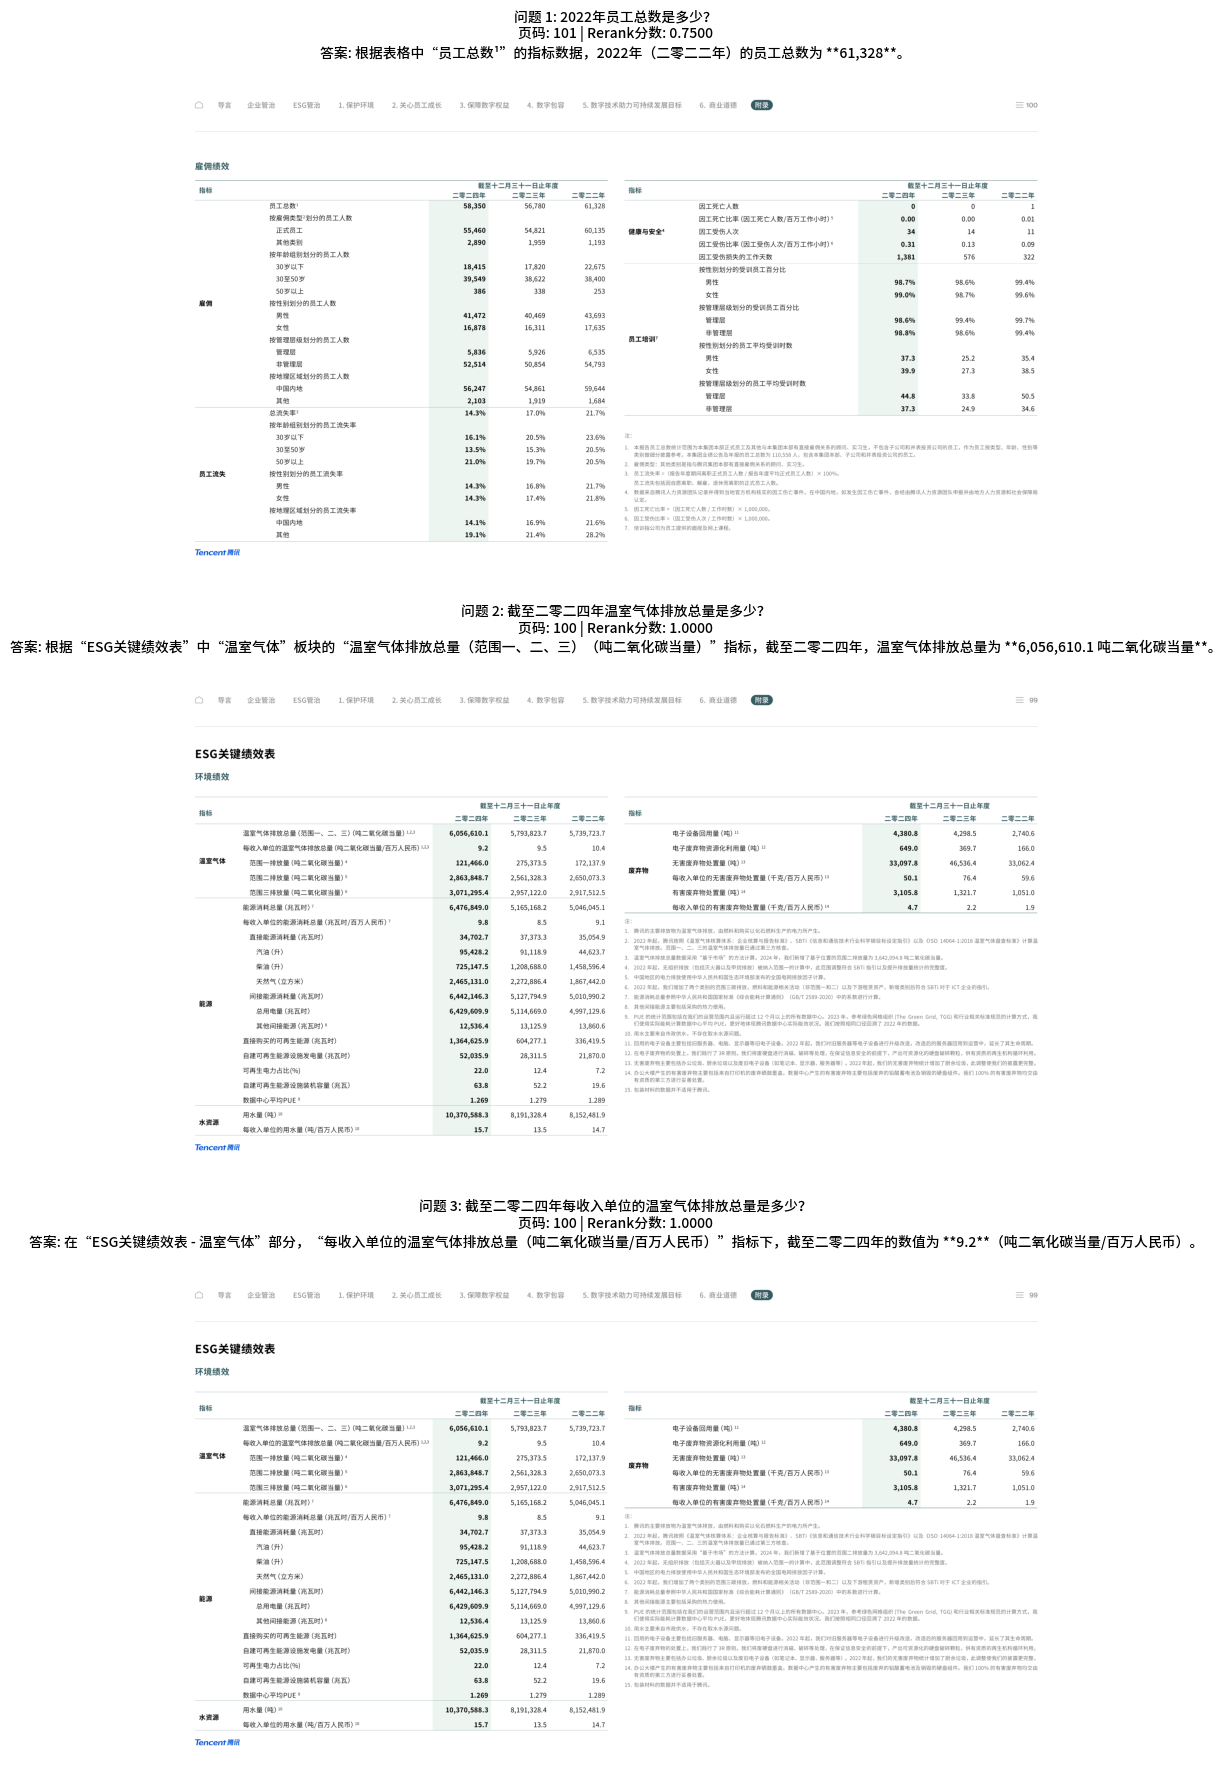


可视化完成！


In [25]:
# 可视化API问答结果
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = "/mnt/SSD2_8TB/zechuan/noto-sans-sc/NotoSansSC-Medium.otf"
font_prop = font_manager.FontProperties(fname=font_path)

num_results = len(api_results)
fig, axes = plt.subplots(num_results, 1, figsize=(12, 6*num_results))

# 确保axes是数组
if num_results == 1:
    axes = [axes]

for idx, result in enumerate(api_results):
    ax = axes[idx]
    ax.imshow(result['image'])
    
    title = f"问题 {idx+1}: {result['query']}\n"
    title += f"页码: {result['page_num']} | Rerank分数: {result['rerank_score']:.4f}\n"
    title += f"答案: {result['answer'][:100]}..." if len(result['answer']) > 100 else f"答案: {result['answer']}"
    
    ax.set_title(title, fontsize=11, fontweight='bold', fontproperties=font_prop, pad=20)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n可视化完成！")

In [ ]:
# 保存API问答结果到JSON文件
import json
from datetime import datetime

# 准备保存的数据（不包含图片对象）
save_data = []
for result in api_results:
    save_data.append({
        'query': result['query'],
        'page_num': result['page_num'],
        'rerank_score': float(result['rerank_score']),
        'answer': result['answer']
    })

# 生成文件名
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"api_qa_results_{timestamp}.json"

# 保存到文件
with open(filename, 'w', encoding='utf-8') as f:
    json.dump(save_data, f, ensure_ascii=False, indent=2)

print(f"结果已保存到: {filename}")